# 02 - Exploratory Data Analysis (EDA)

## Objective

This notebook performs exploratory data analysis on the loan approval
dataset to identify patterns, relationships, distributions, potential
outliers, and data-quality issues that may influence loan approval
decisions.

The analysis focuses on understanding applicant characteristics,
financial information, credit-related variables, and their relationship
with the loan approval outcome.

# Importing libraries for EDA

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Loading Data again

In [3]:
loan_data=pd.read_csv("/workspaces/loan-approval-prediction/data/raw/loan_data_new.csv")

loan_data.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


# Questions that rises here
1. What are the demographic, educational, employment, financial, and credit characteristics of the applicants in the loan dataset?
2. What is the distribution of loan approval outcomes, and is there evidence of class imbalance that could affect subsequent machine-learning modelling?
3. How do applicant characteristics such as age, gender, education, home ownership, and employment experience differ between the loan-status groups?
4. How do financial characteristics, particularly person income, loan amount, and the proportion of income allocated to the loan, differ between the loan-status groups?
5. What relationship exists between applicant's credit profiles including credit score, credit history, and previous loan history and loan approval outcomes?
6. Does the purpose of the loan influence the likelihood of approval, and are some loan intents associated with substantially different approval rates?
7. What relationships exist among income, loan amount, loan percentage, credit score, credit history, and other numerical variables, and are there potential correlations that should be considered during modelling?
6. Are there extreme, unusual, or logically inconsistent observations in variables such as age, employee experience, income, loan amount, credit score, and loan percentage that may affect subsequent analysis?
7. Are any variables potentially derived from other variables or determined after the loan decision, creating a risk of data leakage in the machine-learning models?
8. Which variables and observed relationships provide sufficient evidence to warrant further investigation during feature engineering and model development?

# Assessing target analysis

In [4]:
loan_data["Loan Status"].value_counts()

Loan Status
0    35000
1    10000
Name: count, dtype: int64

In [5]:
loan_data["Loan Status"].value_counts(normalize=True).mul(100)

Loan Status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

Visualisation of target variable:

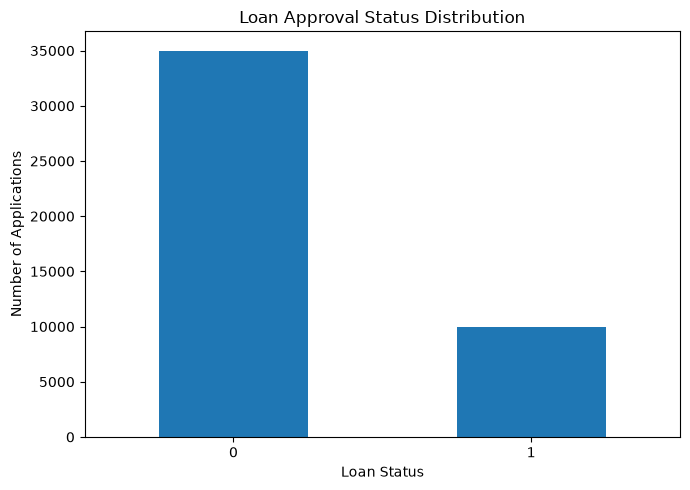

In [4]:
loan_data["Loan Status"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Category Analysis:

In [5]:
categorical_cols = [
    "Gender",
    "Education",
    "Home Onwership",
    "Loan Intent",
    "Previous Loan"
]

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    print(loan_data[col].value_counts())


Gender
Gender
male      24841
female    20159
Name: count, dtype: int64

Education
Education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

Home Onwership
Home Onwership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

Loan Intent
Loan Intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Previous Loan
Previous Loan
Yes    22858
No     22142
Name: count, dtype: int64


Calculatng approval rates using categories:

In [6]:
for col in categorical_cols:
    approval_rate = pd.crosstab(
        loan_data[col],
        loan_data["Loan Status"],
        normalize="index"
    ) * 100
    
    print(f"\n{col}")
    display(approval_rate.round(2))


Gender


Loan Status,0,1
Gender,,
female,77.75,22.25
male,77.80,22.20



Education


Loan Status,0,1
Education,,
Associate,77.97,22.03
Bachelor,77.48,22.52
Doctorate,77.13,22.87
High School,77.69,22.31
Master,78.24,21.76



Home Onwership


Loan Status,0,1
Home Onwership,,
MORTGAGE,88.40,11.60
OTHER,66.67,33.33
OWN,92.48,7.52
RENT,67.60,32.40



Loan Intent


Loan Status,0,1
Loan Intent,,
DEBTCONSOLIDATION,69.73,30.27
EDUCATION,83.04,16.96
HOMEIMPROVEMENT,73.70,26.30
MEDICAL,72.18,27.82
PERSONAL,79.86,20.14
VENTURE,85.57,14.43



Previous Loan


Loan Status,0,1
Previous Loan,,
No,54.84,45.16
Yes,100.00,0.00


The above analysis should answer this question: "Does the outcome distribution differ across applicant groups?"

# Numerical variables

In [7]:
numerical_cols = [
    "Age",
    "Person Income",
    "Employee Experience",
    "Loan Amount",
    "Loan interest Rate",
    "Loan percentage",
    "Credit History",
    "Credit Score"
]

In [8]:
loan_data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
Person Income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
Employee Experience,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
Loan Amount,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
Loan interest Rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
Loan percentage,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
Credit History,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
Credit Score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00


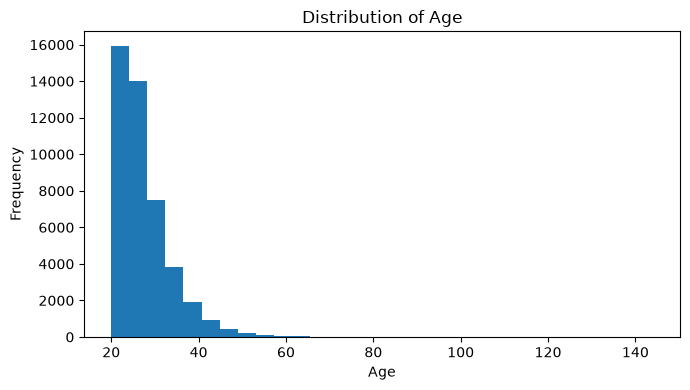

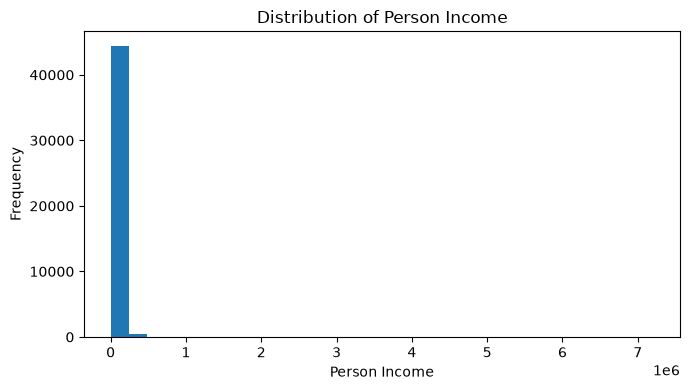

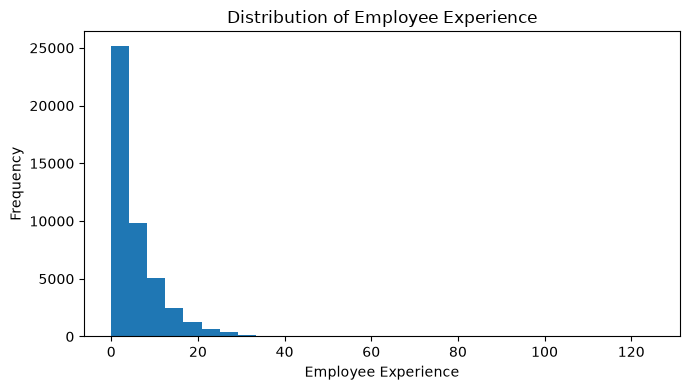

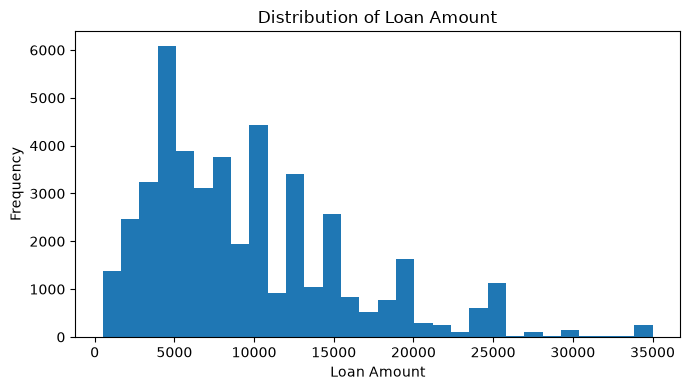

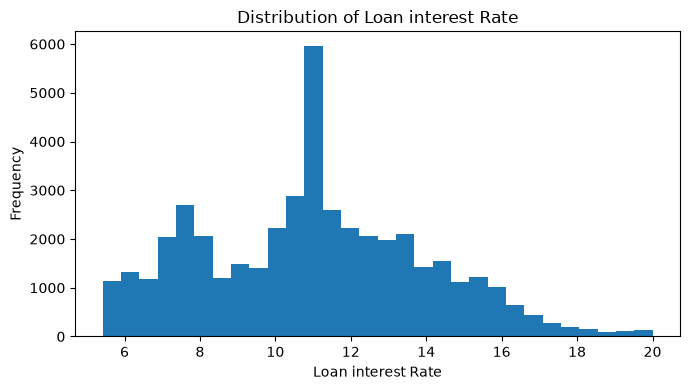

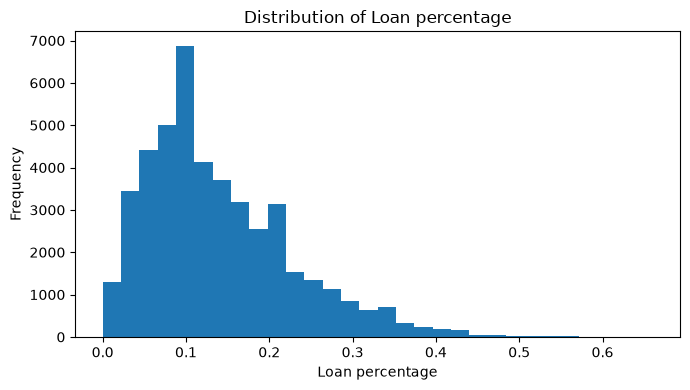

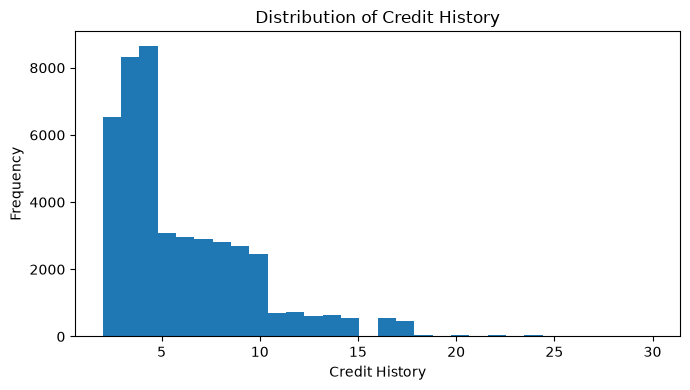

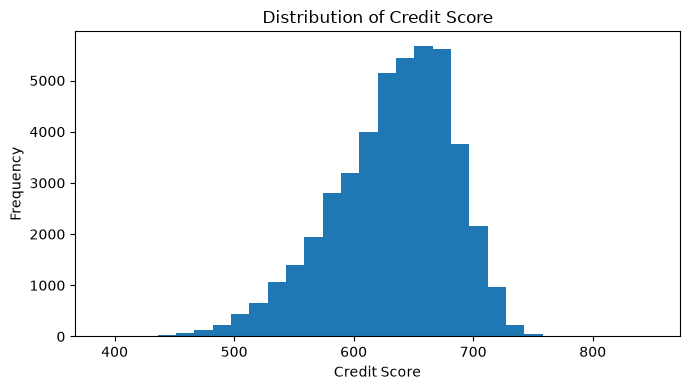

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    
    plt.hist(loan_data[col], bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

Compare numerical variables by loan status

<Figure size 700x400 with 0 Axes>

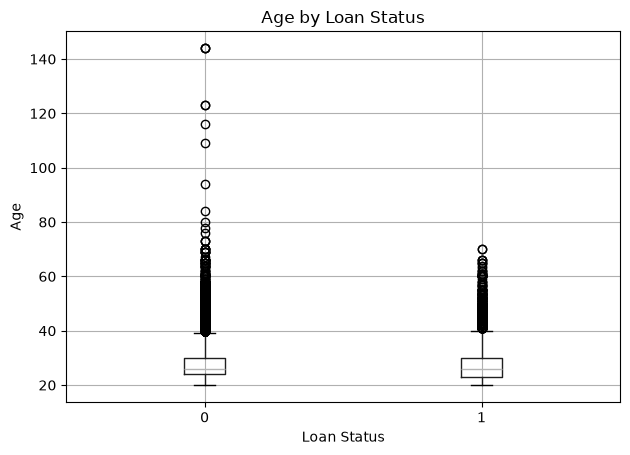

<Figure size 700x400 with 0 Axes>

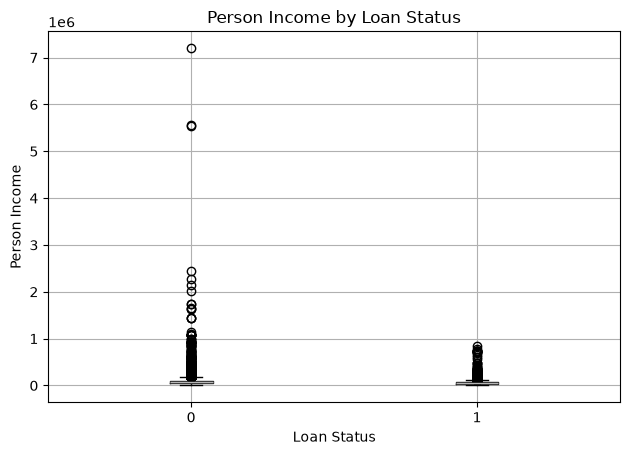

<Figure size 700x400 with 0 Axes>

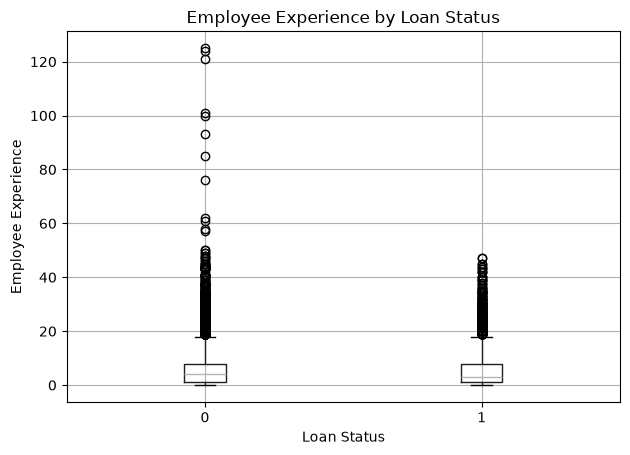

<Figure size 700x400 with 0 Axes>

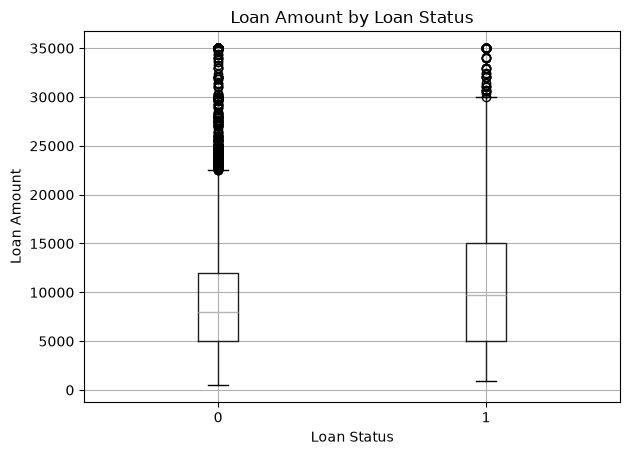

<Figure size 700x400 with 0 Axes>

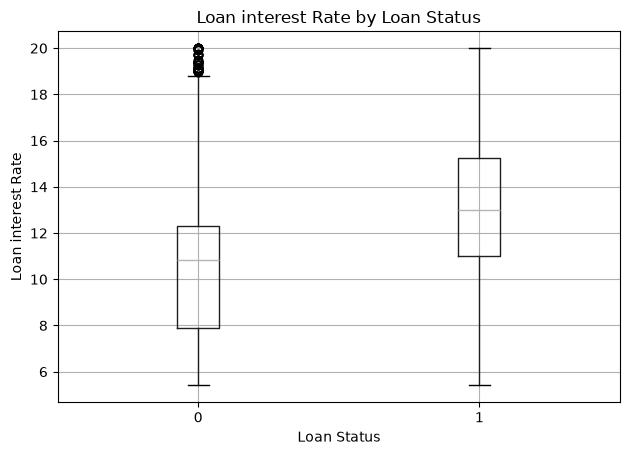

<Figure size 700x400 with 0 Axes>

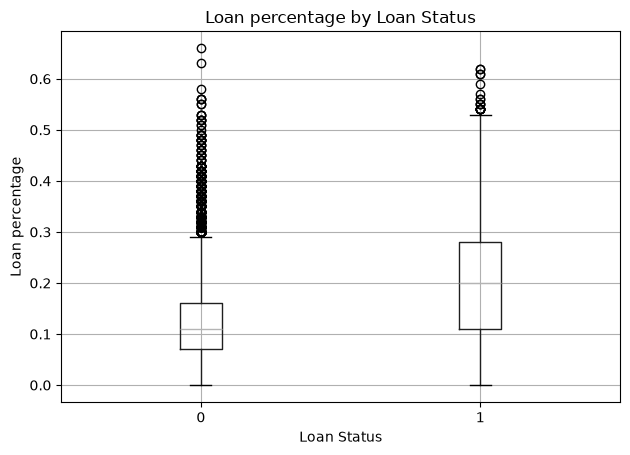

<Figure size 700x400 with 0 Axes>

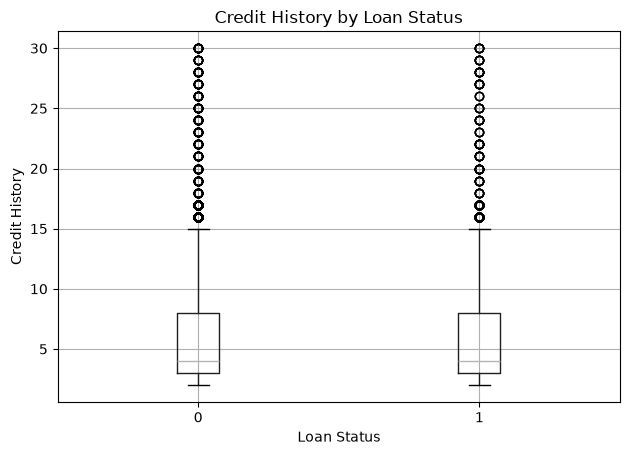

<Figure size 700x400 with 0 Axes>

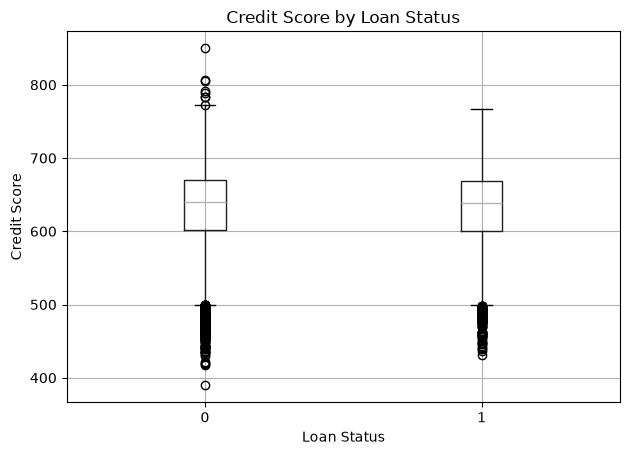

In [10]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    
    loan_data.boxplot(
        column=col,
        by="Loan Status"
    )
    
    plt.title(f"{col} by Loan Status")
    plt.suptitle("")
    plt.xlabel("Loan Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

This identify whether numerical variables such as credit score, income, loan amount and loan percentage differ between the two outcome groups.

In [11]:
approval_by_credit_score = (
    loan_data
    .groupby("Credit Score")["Loan Status"]
    .mean()
    .reset_index()
)

approval_by_credit_score.head()

,Credit Score,Loan Status
0,390,0.0
1,418,0.0
2,419,0.0
3,420,0.0
4,421,0.0


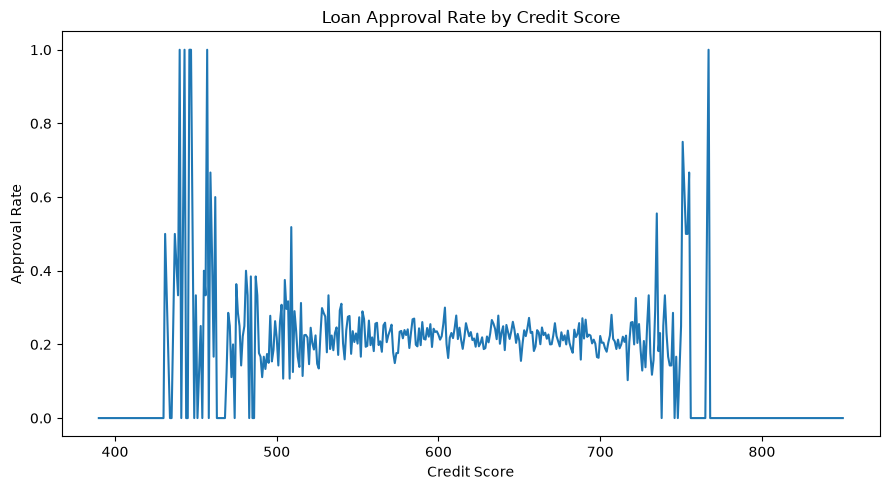

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    approval_by_credit_score["Credit Score"],
    approval_by_credit_score["Loan Status"]
)

plt.title("Loan Approval Rate by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Approval Rate")
plt.tight_layout()
plt.show()

# Correlation analysis

In [13]:
correlation = loan_data[numerical_cols + ["Loan Status"]].corr()

correlation.round(2)

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
Age,1.00,0.19,0.95,0.05,0.01,-0.04,0.86,0.18,-0.02
Person Income,0.19,1.00,0.19,0.24,0.00,-0.23,0.12,0.04,-0.14
Employee Experience,0.95,0.19,1.00,0.04,0.02,-0.04,0.82,0.19,-0.02
Loan Amount,0.05,0.24,0.04,1.00,0.15,0.59,0.04,0.01,0.11
Loan interest Rate,0.01,0.00,0.02,0.15,1.00,0.13,0.02,0.01,0.33
Loan percentage,-0.04,-0.23,-0.04,0.59,0.13,1.00,-0.03,-0.01,0.38
Credit History,0.86,0.12,0.82,0.04,0.02,-0.03,1.00,0.16,-0.01
Credit Score,0.18,0.04,0.19,0.01,0.01,-0.01,0.16,1.00,-0.01
Loan Status,-0.02,-0.14,-0.02,0.11,0.33,0.38,-0.01,-0.01,1.00


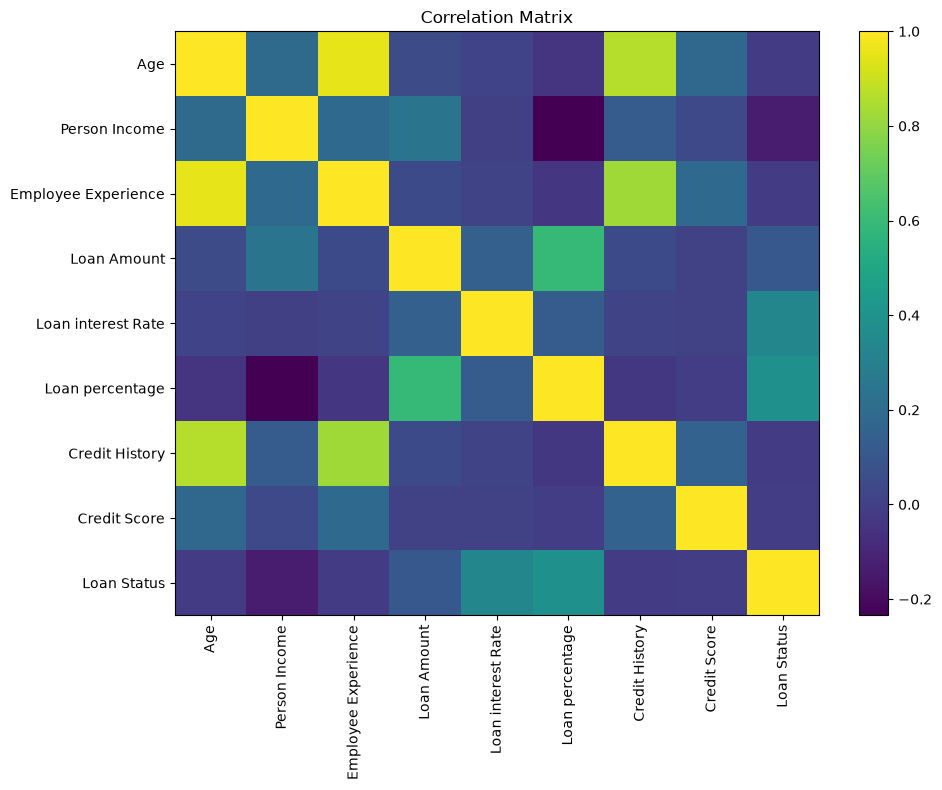

In [15]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

Inspecting the extreme observations

In [16]:
loan_data[
    (loan_data["Age"] > 80) |
    (loan_data["Employee Experience"] > 50)
][[
    "Age",
    "Employee Experience",
    "Credit History",
    "Credit Score",
    "Person Income",
    "Loan Amount",
    "Loan Status"
]]

,Age,Employee Experience,Credit History,Credit Score,Person Income,Loan Amount,Loan Status
81,144,125,3,789,300616,4800,0
183,144,121,2,807,241424,6000,0
575,123,101,3,805,97140,20400,0
747,123,100,4,714,94723,20000,0
32297,144,124,25,850,7200766,5000,0
32355,78,57,25,754,58463,3000,0
32416,94,76,27,773,29738,6500,0
32422,80,62,25,673,77894,6800,0
32506,84,61,24,784,114705,10000,0
32534,76,58,25,737,90934,15000,0


Check the Age and Employment-experience relationship

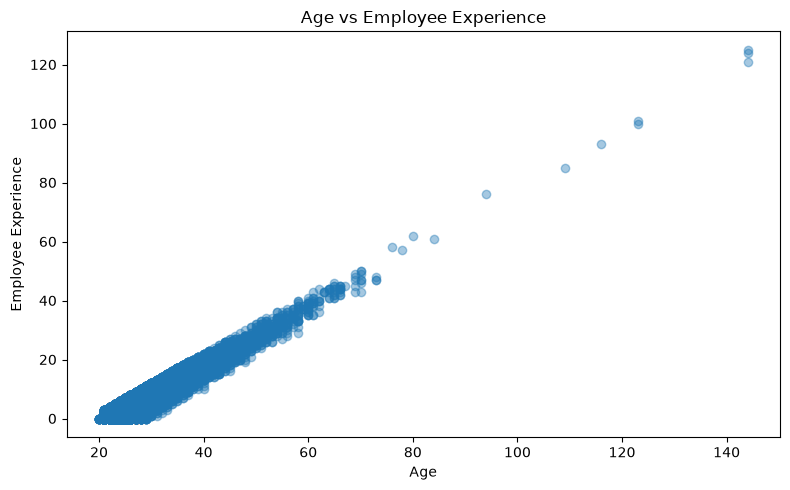

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    loan_data["Age"],
    loan_data["Employee Experience"],
    alpha=0.4
)

plt.title("Age vs Employee Experience")
plt.xlabel("Age")
plt.ylabel("Employee Experience")
plt.tight_layout()
plt.show()

Checking approval rates by credit score

In [18]:
loan_data["Credit Score Group"] = pd.cut(
    loan_data["Credit Score"],
    bins=[0, 500, 550, 600, 650, 700, 750, 800, 900],
    right=False
)

credit_approval = (
    loan_data.groupby("Credit Score Group", observed=False)["Loan Status"]
    .mean()
    .mul(100)
)

credit_approval

Credit Score Group
[0, 500)      21.146245
[500, 550)    23.082764
[550, 600)    22.398543
[600, 650)    22.617726
[650, 700)    21.836492
[700, 750)    21.156559
[750, 800)    25.714286
[800, 900)     0.000000
Name: Loan Status, dtype: float64

In [19]:
loan_data["Credit Score Group"].value_counts().sort_index()

Credit Score Group
[0, 500)        506
[500, 550)     2634
[550, 600)     7688
[600, 650)    15311
[650, 700)    15987
[700, 750)     2836
[750, 800)       35
[800, 900)        3
Name: count, dtype: int64

In [20]:
credit_score_analysis = (
    loan_data
    .groupby("Credit Score Group", observed=False)
    .agg(
        Applications=("Loan Status", "size"),
        Approval_Rate=("Loan Status", "mean")
    )
)

credit_score_analysis["Approval_Rate"] *= 100

credit_score_analysis.round(2)

,Applications,Approval_Rate
Credit Score Group,,
"[0, 500)",506,21.15
"[500, 550)",2634,23.08
"[550, 600)",7688,22.40
"[600, 650)",15311,22.62
"[650, 700)",15987,21.84
"[700, 750)",2836,21.16
"[750, 800)",35,25.71
"[800, 900)",3,0.00


The highest credit-score categories contain very few observations, particularly the 800–899 group with only three applications. Consequently, approval rates in these groups should not be interpreted as reliable estimates of the underlying approval probability.

# Credit Score and Loan Approval:
The distribution of loan approval rates across credit-score groups shows relatively little variation across the main concentration of observations. Approval rates range from 21.15% to 23.08% for credit-score groups containing the majority of applicants, which is consistent with the near-zero Pearson correlation between credit score and loan status. Although the 750 - 799 group has a slightly higher approval rate of 25.71%, it contains only 35 applications. Similarly, the 800 - 899 group contains only three applications and records no approved applications. Therefore, these higher-score groups provide insufficient observations to support reliable conclusions. Overall, the exploratory analysis does not indicate a strong monotonic relationship between credit score and loan approval in the observed data

# Comparing each credit-score group against the data average

In [21]:
overall_approval = loan_data["Loan Status"].mean() * 100
overall_approval

np.float64(22.22222222222222)

The overall approval rate is approximately 22.22%. Most credit-score groups have approval rates close to this overall rate, suggesting limited variation in approval outcomes across the main credit-score ranges.

# Distribution of credit score

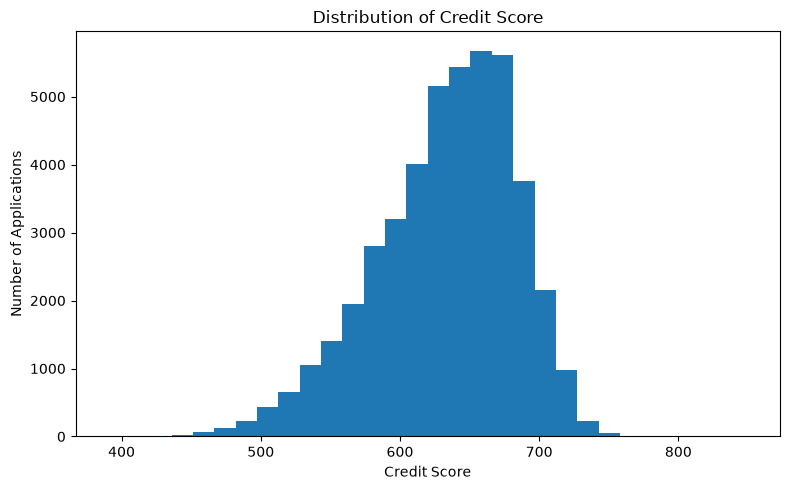

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(loan_data["Credit Score"], bins=30)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.show()

# Boxplot by Loan Status

<Figure size 700x500 with 0 Axes>

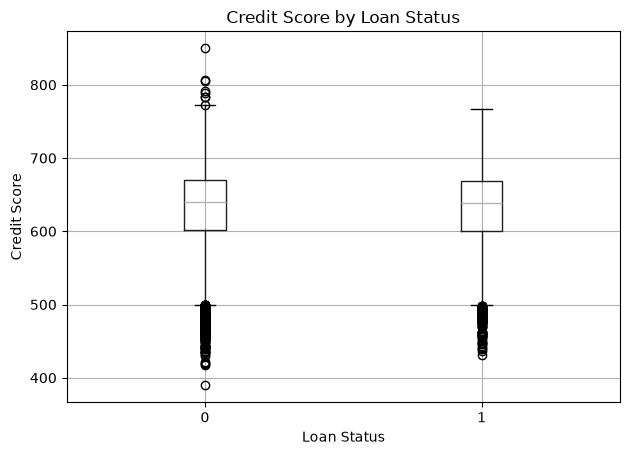

In [23]:
plt.figure(figsize=(7, 5))

loan_data.boxplot(
    column="Credit Score",
    by="Loan Status"
)

plt.title("Credit Score by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.show()

Does approval rate differ between applicants in the lower and higher portions of the credit-score distribution?

In [24]:
loan_data["Credit Score Quartile"] = pd.qcut(
    loan_data["Credit Score"],
    q=4,
    duplicates="drop"
)

credit_quartile = (
    loan_data
    .groupby("Credit Score Quartile", observed=False)
    .agg(
        Applications=("Loan Status", "size"),
        Approval_Rate=("Loan Status", "mean")
    )
)

credit_quartile["Approval_Rate"] *= 100

credit_quartile.round(2)

,Applications,Approval_Rate
Credit Score Quartile,,
"(389.999, 601.0]",11265,22.49
"(601.0, 640.0]",11566,22.57
"(640.0, 670.0]",11235,22.20
"(670.0, 850.0]",10934,21.60


The quartile analysis shows that loan approval rates are relatively stable across the distribution of credit scores, ranging from 21.60% to 22.57%. The highest approval rate is observed in the second quartile (22.57%), while the highest credit-score quartile has the lowest approval rate (21.60%). Therefore, the exploratory analysis does not indicate a strong monotonic relationship between credit score and loan approval. However, this does not imply that credit score has no predictive value, as nonlinear relationships and interactions with other applicant characteristics may not be captured by correlation or grouped approval rates. Credit score will therefore be retained for subsequent feature engineering and machine-learning model evaluation.